# Exploratory Data Analysis: Data Science Salaries

This project looks at a dataset of data science employee salaries, including job roles, experience levels, company size, and location.  
The goal is to understand salary patterns, compare different roles and experience levels, and find insights that explain differences in pay.


In [1]:
# import libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

# Importance of columns to Target column
from itertools import combinations
from scipy.stats import chi2_contingency as chi

# For Model building
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.model_selection import train_test_split

import category_encoders as ce


# ignore warnings 
import warnings
warnings.filterwarnings("ignore")

# view max rows and columns 
pd.set_option("display.max_rows",None)
pd.set_option("display.max_columns",None)

#- install following Pip in Jupiter notebook
#- then run the following codes.
#!pip install category_encoders 

In [2]:
data=pd.read_csv("ds_salaries.csv")

In [3]:
data.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


### Data dictionery

- experience level =  EN(Entry level) , MI(Mid level) , SE(Seniors) , EX(Executive)    
- employment type = FT(Full-Time) , PT(Part-Time) , CT(Contract) , FL(Freelance)
- job_title = designation of the employee
- Remote = 100(Fully remote), 0(On-site) ,  50(Hybrid)

### Data shapes

In [4]:
print(f"This data had {data.shape[0]} rows and {data.shape[1]} columns")

This data had 3755 rows and 11 columns


### Numerical & categorical columns 

In [5]:
nums_cols = []
cats_cols = []

for col in data.columns:
    if data[col].dtype =="O":
        cats_cols.append(col)
    else:
        nums_cols.append(col)
print(f"Total number of Numerical columns are {len(nums_cols)} & Categorical columns are {len(cats_cols)}")


Total number of Numerical columns are 4 & Categorical columns are 7


### Missing and Duplicates 

In [6]:
pd.DataFrame({
    "data types":data.dtypes,
    "missing values":data.isnull().sum(),
    "duplicates(rows)":data.duplicated().sum(),
    "unique values":data.apply(lambda x:x.nunique())})

,data types,missing values,duplicates(rows),unique values
work_year,int64,0,1171,4
experience_level,object,0,1171,4
employment_type,object,0,1171,4
job_title,object,0,1171,93
salary,int64,0,1171,815
salary_currency,object,0,1171,20
salary_in_usd,int64,0,1171,1035
employee_residence,object,0,1171,78
remote_ratio,int64,0,1171,3
company_location,object,0,1171,72


In [7]:
data[data.duplicated(keep=False)].head(10)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
5,2023,SE,FT,Applied Scientist,222200,USD,222200,US,0,US,L
6,2023,SE,FT,Applied Scientist,136000,USD,136000,US,0,US,L
9,2023,SE,FT,Data Scientist,147100,USD,147100,US,0,US,M
10,2023,SE,FT,Data Scientist,90700,USD,90700,US,0,US,M
11,2023,SE,FT,Data Analyst,130000,USD,130000,US,100,US,M
12,2023,SE,FT,Data Analyst,100000,USD,100000,US,100,US,M
13,2023,EN,FT,Applied Scientist,213660,USD,213660,US,0,US,L
14,2023,EN,FT,Applied Scientist,130760,USD,130760,US,0,US,L
17,2023,SE,FT,Data Scientist,170000,USD,170000,US,0,US,M
18,2023,SE,FT,Data Scientist,150000,USD,150000,US,0,US,M


### Dropping the duplicates 

In [8]:
data[data.duplicated(keep=False)].shape

(1715, 11)

In [9]:
data.drop_duplicates(inplace = True)

In [10]:
data[data.duplicated(keep=False)].shape

(0, 11)

In [11]:
data.shape

(2584, 11)

### data sample 

In [12]:
data_sample=data.head(5).T
data_sample=data_sample.rename(columns={0:"sample_1",1:"sample_2",2:"sample_3",3:"sample_4",4:"sampel_5"})
dtypes_df = pd.DataFrame(data.dtypes, columns=["data_type"])
pd.concat((dtypes_df,data_sample),axis = 1)

,data_type,sample_1,sample_2,sample_3,sample_4,sampel_5
work_year,int64,2023,2023,2023,2023,2023
experience_level,object,SE,MI,MI,SE,SE
employment_type,object,FT,CT,CT,FT,FT
job_title,object,Principal Data Scientist,ML Engineer,ML Engineer,Data Scientist,Data Scientist
salary,int64,80000,30000,25500,175000,120000
salary_currency,object,EUR,USD,USD,USD,USD
salary_in_usd,int64,85847,30000,25500,175000,120000
employee_residence,object,ES,US,US,CA,CA
remote_ratio,int64,100,100,100,100,100
company_location,object,ES,US,US,CA,CA


In [13]:
data.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## Univariate Analysis

In [14]:
data["work_year"].value_counts(dropna=True)

work_year
2023    1156
2022    1125
2021     228
2020      75
Name: count, dtype: int64

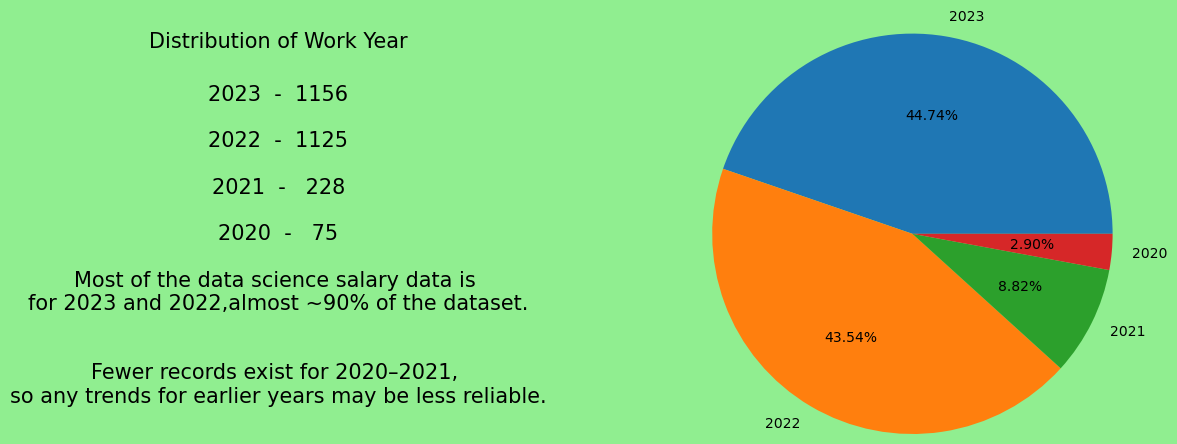

In [15]:
fig, axes = plt.subplots(1,2,figsize=(15,5))
fig.patch.set_facecolor('lightgreen')

axes[0].axis("off")
axes[0].text(0.5,1.0,"Distribution of Work Year",ha="center",va="center",fontsize=15)
years_data = """
2023  -  1156\n
2022  -  1125\n
2021  -   228\n
2020  -   75\n
Most of the data science salary data is \nfor 2023 and 2022,almost ~90% of the dataset.\n\n
Fewer records exist for 2020–2021, \nso any trends for earlier years may be less reliable."""
axes[0].text(0.5,0.5,years_data,ha="center",va="center",fontsize=15)

axes[1].pie(data["work_year"].value_counts(dropna=True),labels=data["work_year"].value_counts(dropna=True).index,autopct = "%.2f%%",radius=1.3)

plt.show()

In [16]:
# lets rename classes of experience_level and employment_type
data["experience_level"]=data["experience_level"].replace({"SE":"Senior","MI":"Mid","EN":"Entry","EX":"Executive"})
data["employment_type"]=data["employment_type"].replace({"FT":"Fulltime","PT":"Parttime","CT":"Contract","FL":"Freelance"})

In [17]:
round(data["employment_type"].value_counts(normalize=True)*100,2)

employment_type
Fulltime     98.57
Parttime      0.66
Contract      0.39
Freelance     0.39
Name: proportion, dtype: float64

In [18]:
round(data["experience_level"].value_counts(normalize=True)*100,2)

experience_level
Senior       60.14
Mid          25.70
Entry        10.45
Executive     3.72
Name: proportion, dtype: float64

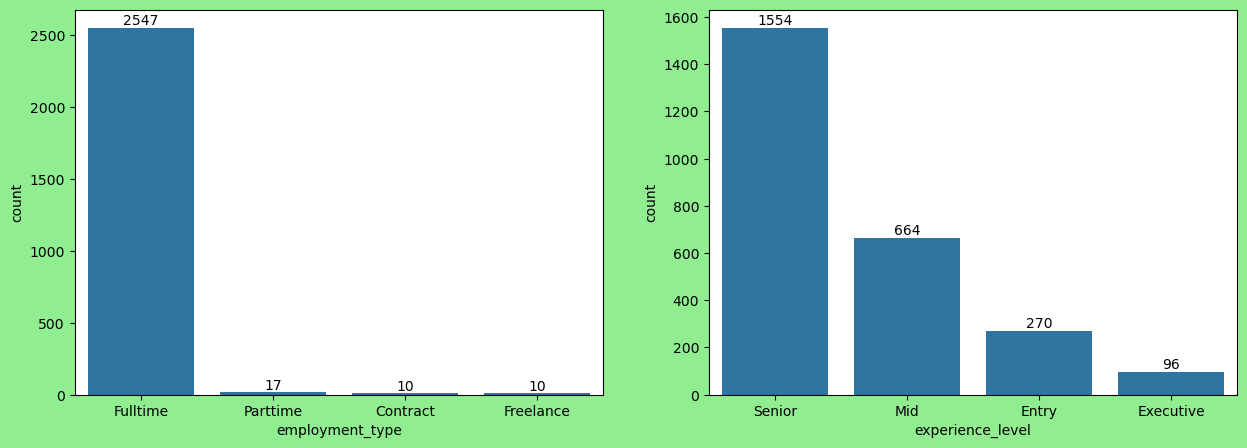

In [19]:
fig , axes = plt.subplots(1,2,figsize = (15,5))
fig.patch.set_facecolor("lightgreen")
axes = axes.flatten()

ax=sns.countplot(x=data["employment_type"],order= data["employment_type"].value_counts(dropna=False).index , ax=axes[0])
ax.bar_label(ax.containers[0])
ax=sns.countplot(x=data["experience_level"],order= data["experience_level"].value_counts(dropna=False).index , ax=axes[1])
ax.bar_label(ax.containers[0])

plt.show()

In [20]:
data["job_title"].nunique()

93

In [21]:
pd.concat([data["job_title"].value_counts(),round(data["job_title"].value_counts(normalize=True)*100,2)],axis=1)

,count,proportion
job_title,,
Data Engineer,598,23.14
Data Scientist,538,20.82
Data Analyst,396,15.33
Machine Learning Engineer,206,7.97
Analytics Engineer,91,3.52
Research Scientist,65,2.52
Data Architect,64,2.48
Data Science Manager,52,2.01
ML Engineer,34,1.32


In [22]:
data["company_size"]=data["company_size"].replace({"M":"Mid size","L":"Large size","S":"Small size"})
pd.concat([data["company_size"].value_counts(dropna=True),round(data["company_size"].value_counts(normalize =True)*100,2)],axis=1)

,count,proportion
company_size,,
Mid size,2028,78.48
Large size,409,15.83
Small size,147,5.69


In [23]:
## changing the remote ratio names for convience and also changing the data type 
data["remote_ratio"]=data["remote_ratio"].replace({100:"Fully remote",50:"Hybrid",0:"On-site"})
data["remote_ratio"]=data["remote_ratio"].astype("object")

In [24]:
data["remote_ratio"].value_counts()

remote_ratio
Fully remote    1211
On-site         1186
Hybrid           187
Name: count, dtype: int64

In [25]:
pd.concat([data["company_location"].value_counts(),round(data["company_location"].value_counts(normalize =True)*100,2)],axis=1)

,count,proportion
company_location,,
US,1929,74.65
GB,155,6.00
CA,83,3.21
IN,57,2.21
DE,55,2.13
ES,44,1.70
FR,33,1.28
BR,15,0.58
AU,14,0.54


In [26]:
pd.concat([data["employee_residence"].value_counts(),round(data["employee_residence"].value_counts(normalize =True)*100,2)],axis=1)

,count,proportion
employee_residence,,
US,1893,73.26
GB,150,5.80
CA,81,3.13
IN,70,2.71
ES,47,1.82
DE,47,1.82
FR,37,1.43
PT,18,0.70
BR,18,0.70


## KeyPoint

- We'll use 'salary_in_usd' as the target column because all salaries are in USD now.  
- Remove 'salary' and 'salary_currency' since we don't need them anymore as it leads to confuse the model further.


In [27]:
data.drop(columns=["salary","salary_currency"],inplace=True)

In [28]:
data.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,Senior,Fulltime,Principal Data Scientist,85847,ES,Fully remote,ES,Large size
1,2023,Mid,Contract,ML Engineer,30000,US,Fully remote,US,Small size
2,2023,Mid,Contract,ML Engineer,25500,US,Fully remote,US,Small size
3,2023,Senior,Fulltime,Data Scientist,175000,CA,Fully remote,CA,Mid size
4,2023,Senior,Fulltime,Data Scientist,120000,CA,Fully remote,CA,Mid size


In [29]:
data["salary_in_usd"].describe()

count      2584.000000
mean     133409.280186
std       67136.837329
min        5132.000000
25%       84975.000000
50%      130000.000000
75%      175000.000000
max      450000.000000
Name: salary_in_usd, dtype: float64

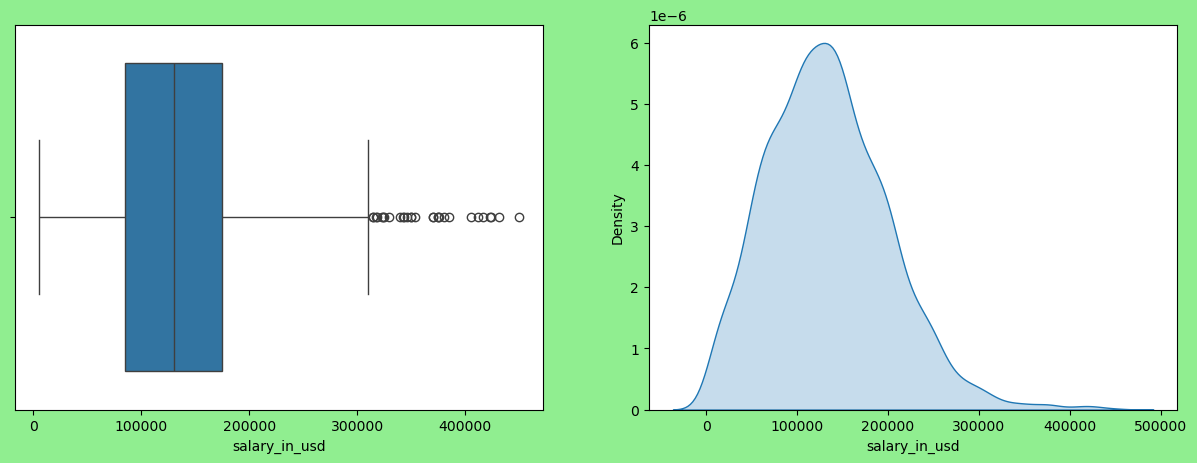

In [30]:
fig , axes = plt.subplots(1,2,figsize=(15,5))
fig.patch.set_facecolor("lightgreen")
axes = axes.flatten()

sns.boxplot(x=data["salary_in_usd"],ax=axes[0])
sns.kdeplot(x=data["salary_in_usd"],fill=True,ax=axes[1])
plt.show()

In [31]:
# outliers detection
q1=data["salary_in_usd"].quantile(0.25)
q3=data["salary_in_usd"].quantile(0.75)
IQR=q3-q1
upper_fence=q3+(IQR*1.5)
lower_fence=q1-(IQR*1.5)
print(f"Any values below the lower fence { lower_fence } and beyond upper fence { upper_fence } are said to be outliers")

Any values below the lower fence -50062.5 and beyond upper fence 310037.5 are said to be outliers


In [32]:
upper_fence_outliers= data[data["salary_in_usd"]>upper_fence]
lower_fence_outliers=data[data["salary_in_usd"]<lower_fence]
print(f"Total number of rows beyond the upper fence are {upper_fence_outliers.shape[0]} and below the lower fence { lower_fence_outliers.shape[0]}")

Total number of rows beyond the upper fence are 29 and below the lower fence 0


In [33]:
print(data[(data["salary_in_usd"]<84975)].shape)
print(data[(data["salary_in_usd"]>84975)&(data["salary_in_usd"]<130000)].shape)
print(data[(data["salary_in_usd"]>=130000)&(data["salary_in_usd"]<175000)].shape)
print(data[(data["salary_in_usd"]>175000)&(data["salary_in_usd"]<310037.5)].shape)
print(data[(data["salary_in_usd"]>=310037.5)].shape)

(646, 9)
(644, 9)
(629, 9)
(610, 9)
(29, 9)


In [34]:
upper_fence_outliers[["job_title","salary_in_usd"]].sort_values(by="salary_in_usd")

,job_title,salary_in_usd
1396,Head of Data Science,314100
2406,Data Engineer,315000
488,Data Scientist,317070
145,Machine Learning Engineer,318300
1116,Machine Learning Engineer,323300
3410,Data Engineer,324000
3697,Director of Data Science,325000
228,Head of Data,329500
845,Research Scientist,340000
133,Machine Learning Engineer,342300


In [35]:
pd.concat([upper_fence_outliers["job_title"].value_counts(),data["job_title"].value_counts()],axis =1).head(18)                                                                                                      

,count,count
job_title,,
Data Scientist,4.0,538
Research Scientist,3.0,65
Machine Learning Engineer,3.0,206
Data Analyst,2.0,396
Director of Data Science,2.0,11
Data Architect,2.0,64
Data Engineer,2.0,598
Data Science Tech Lead,1.0,1
Principal Data Scientist,1.0,8


## Univariate analysis - Observations 

#### Work-Year
- Most of the data science salary data is for 2023 and 2022, accounting for ~90% of the dataset.
- Fewer records exist for 2020–2021, so any trends for earlier years may be less reliable.
#### Employment type
- Most employees (98%) work full-time, showing that data science jobs usually require full commitment.
#### Experince level
- 60% of employees are Senior-level.
- Mid-level employees make up 25.7%, while entry-level positions are harder to get, only 10.45%.
- Executives are the smallest group at 3.72%.
#### Job titles
- Most jobs (around 70%) are for Data Engineer, Data Scientist, Data Analyst, Machine Learning Engineer, and Analytics Engineer.
- The rest of the 88 job titles make up 30%, but most have only a few openings because they are high-level or very specialized.
- Entry-level or niche roles are hard to get, showing that data science jobs can be competitive.
#### Company size
- Most data science jobs (78%) are in mid-sized companies, possibly because they are often involved in consultancies.
- Small companies have fewer openings (5.7%) since data privacy and reputation concerns make it harder for them to hire.
- Large companies (15.8%) may outsource data science work, reducing the number of in-house roles.
#### Remote (working place)
- Around 47% of employees work fully remote, while 46% work entirely from the office.
- Less than 7% work in a hybrid setup.
- This shows that companies prefer employees to work completely on-site or fully remote.
- It is mainly due to data privacy, security concerns, and the need for continuous communication.
#### Company location
- Most companies are based in the US (around 75%), followed by the GB or united kingdom (6%).
- This is likely because many major tech companies are headquartered in the US.
#### Employee residence
- Since most companies are based in the US, the majority of employees are also from the US (around 73%), followed by the GB or united kingdom (5.8%).
- This suggests that companies prefer on-site work and therefore hire local employees or expect candidates to relocate.
#### Salary in USD
- The average salary for Data Science employees is around 133,000 USD, and 50% of them earn between 85,000 and 175,000 USD.  
- The boxplot shows that there are outliers in the 'salary_in_usd' column.  
- However, these are not true outliers, so we will keep them as they provide useful information for model building.


In [36]:
filtered_data = data[data["employee_residence"] != data["company_location"]]
filtered_data.shape

(96, 9)

- Out of 2,584 employees, only 96 have a residence different from their company location.

In [37]:
filtered_data[["job_title","employee_residence","company_location","remote_ratio"]]

,job_title,employee_residence,company_location,remote_ratio
81,Machine Learning Engineer,PT,US,Fully remote
82,Applied Machine Learning Engineer,IN,DE,Fully remote
183,Staff Data Analyst,NG,CA,On-site
218,Applied Data Scientist,AU,FI,Fully remote
249,Data Scientist,ES,GB,Fully remote
604,Data Scientist,AT,DE,Fully remote
736,AI Programmer,IN,AU,On-site
856,Software Data Engineer,NG,AU,Hybrid
857,Data Analyst,UZ,US,Fully remote
974,Data Science Manager,UZ,RU,On-site


In [38]:
filtered_data.groupby("remote_ratio")[["employee_residence","company_location"]].count()

,employee_residence,company_location
remote_ratio,,
Fully remote,71,71
Hybrid,18,18
On-site,7,7


In [39]:
filtered_data.loc[filtered_data["remote_ratio"] == "On-site", 
                  ["job_title", "employee_residence", "company_location","salary_in_usd","remote_ratio" ,"employment_type"]]

,job_title,employee_residence,company_location,salary_in_usd,remote_ratio,employment_type
183,Staff Data Analyst,NG,CA,15000,On-site,Fulltime
736,AI Programmer,IN,AU,70000,On-site,Fulltime
974,Data Science Manager,UZ,RU,106000,On-site,Fulltime
3621,Research Scientist,JE,CN,100000,On-site,Fulltime
3664,Data Engineer,RO,US,26005,On-site,Fulltime
3696,Data Engineer,IT,US,20000,On-site,Freelance
3705,Big Data Engineer,IN,CH,5882,On-site,Fulltime


In [40]:
filtered_data.loc[filtered_data["remote_ratio"] == "Hybrid", 
                  ["job_title", "employee_residence", "company_location","salary_in_usd","remote_ratio" ,"employment_type"]]

,job_title,employee_residence,company_location,salary_in_usd,remote_ratio,employment_type
856,Software Data Engineer,NG,AU,50000,Hybrid,Freelance
1224,Data Analyst,KW,US,50000,Hybrid,Fulltime
1445,Data Scientist,CY,EE,63312,Hybrid,Fulltime
1549,Data Analytics Lead,IN,SG,17509,Hybrid,Fulltime
2022,3D Computer Vision Researcher,CA,AL,10000,Hybrid,Fulltime
2335,Autonomous Vehicle Technician,AS,BS,45555,Hybrid,Freelance
2501,Data Analyst,CN,US,125404,Hybrid,Parttime
2703,Data Analyst,CR,US,20000,Hybrid,Fulltime
2871,Data Scientist,US,DE,50000,Hybrid,Fulltime
3501,Big Data Engineer,ES,RO,60000,Hybrid,Fulltime


### Insight

- When an employee's residence is different from the company location, they are usually Fully remote.  
  However, seven employees work On-site, which suggests they have relocated.  
- On-site employees generally earn less than the average salary, which may explain why companies prefer them to relocate even if their residence is different.  
- Hybrid employees with a different residence also tend to earn less than the average salary, with only one exception.


In [41]:
nums_cols = []
cats_cols = []

for col in data.columns:
    if data[col].dtype =="O":
        cats_cols.append(col)
    else:
        nums_cols.append(col)
print(f"Total number of Numerical columns are {len(nums_cols)} & Categorical columns are {len(cats_cols)}")


Total number of Numerical columns are 2 & Categorical columns are 7


In [42]:
data.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,Senior,Fulltime,Principal Data Scientist,85847,ES,Fully remote,ES,Large size
1,2023,Mid,Contract,ML Engineer,30000,US,Fully remote,US,Small size
2,2023,Mid,Contract,ML Engineer,25500,US,Fully remote,US,Small size
3,2023,Senior,Fulltime,Data Scientist,175000,CA,Fully remote,CA,Mid size
4,2023,Senior,Fulltime,Data Scientist,120000,CA,Fully remote,CA,Mid size


In [43]:
## lets check the correlation between the cats cols (with chi2 and cramers)

chi2_results=[]
for i , j in combinations(cats_cols,2):
    if (i != j)&(j !=i) :
        cross_table = pd.crosstab(data[i], data[j])
        chi2,p,_,_ = chi(cross_table)                         # chi squared test (shows if there is any relation among the cats cols

        n= cross_table.sum().sum()
        k=min(cross_table.shape)
        cramers_v=np.sqrt(chi2/(n*(k-1)))                    # Cramer_v strength of the relation ( 0:no association , 1: strong association)

        
        chi2_results.append({'Column 1': i, 'Column 2': j, 'Chi2': chi2, 'p-value': round(p,5),"cramers_v":cramers_v})
pd.DataFrame(chi2_results)     

,Column 1,Column 2,Chi2,p-value,cramers_v
0,experience_level,employment_type,108.333465,0.0,0.118216
1,experience_level,job_title,980.444660,0.0,0.355635
2,experience_level,employee_residence,854.935246,0.0,0.332093
3,experience_level,remote_ratio,179.583210,0.0,0.186411
4,experience_level,company_location,850.981647,0.0,0.331324
5,experience_level,company_size,249.635194,0.0,0.219782
6,employment_type,job_title,1042.497669,0.0,0.366717
7,employment_type,employee_residence,1788.038482,0.0,0.480266
8,employment_type,remote_ratio,72.338388,0.0,0.118310
9,employment_type,company_location,1379.793964,0.0,0.421891


## Insights
- All p-values < 0.05, so statistically, all pairs show some level of association.
- Moderate Cramér’s V (0.35-.45) indicates variables share meaningful information.
- Weak Cramér’s V means variables are nearly independent and do not strongly influence each other.

In [44]:
# we can do the ttest or anova based on the classes in the cats cols 
for cols in cats_cols:
    print(cols,":",data[cols].nunique())

experience_level : 4
employment_type : 4
job_title : 93
employee_residence : 78
remote_ratio : 3
company_location : 72
company_size : 3


- All categorical columns have more than two categories,so we will use ANOVA.
- ANOVA checks the difference of means between the groups(between columns) and within the groups.
- If p-value < 0.05 → there is a significant difference in means,meaning the column is useful for the numeric target.
- If p-value >= 0.05 → no significant difference,meaning the column may not be useful.

In [45]:
# Remote ratio with salary (ANOVA)  [ Manual ]
groups = {}

for uni in data["remote_ratio"].unique():
    groups[uni] = data[data["remote_ratio"] == uni]["salary_in_usd"]


from scipy.stats import f_oneway
f_stat,p_value = f_oneway(*groups.values())
print(f_stat)
print(round(p_value,5))

81.6130987241488
0.0


In [46]:
# Remote ratio with salary (ANOVA)  [ code ]
from statsmodels.formula.api import ols
import statsmodels.api as sm


model = ols("salary_in_usd ~ C(remote_ratio)",data=data).fit()
anova_table = sm.stats.anova_lm(model)
print(anova_table)

                     df        sum_sq       mean_sq          F        PR(>F)
C(remote_ratio)     2.0  6.924942e+11  3.462471e+11  81.613099  4.280862e-35
Residual         2581.0  1.095000e+13  4.242543e+09        NaN           NaN


- There is a very strong and statistically significant difference in average salaries across the different remote ratio categories (0%, 50%, 100%).
- So we can ***keep*** this Remote ratio column for out ***Data model***

In [47]:
## lets build a Anova loop for all the categoriacl columns with Target column
from statsmodels.formula.api import ols
import statsmodels.api as sm 

cats_anova = {}


for cols in cats_cols:
    anova_model = ols(f"salary_in_usd ~ C({cols})",data=data).fit()
    anova_table = sm.stats.anova_lm(anova_model)
    cats_anova[cols]=anova_table.iloc[0]                   # Only C factor not residual 


anova_summary = pd.DataFrame(cats_anova).T 
anova_summary

,df,sum_sq,mean_sq,F,PR(>F)
experience_level,3.0,2.630607e+12,8.768690e+11,251.037430,6.287063e-143
employment_type,3.0,2.230653e+11,7.435509e+10,16.799094,8.304623e-11
job_title,92.0,1.805441e+12,1.962436e+10,4.969401,1.233142e-44
employee_residence,77.0,3.792329e+12,4.925103e+10,15.722348,6.041416e-161
remote_ratio,2.0,6.924942e+11,3.462471e+11,81.613099,4.280862e-35
company_location,71.0,3.482501e+12,4.904931e+10,15.099497,9.087113e-145
company_size,2.0,7.443250e+11,3.721625e+11,88.138762,9.383386e-38


- All of categorical variables have extremely small p-values (much smaller than 0.05), which means:
- There is strong evidence that the mean salary differs across the groups of each categorical variable.
- In other words, all these categorical columns are statistically significant predictors of salary_in_usd.

In [48]:
# correlation between the nums cols 
data[nums_cols].corr()

,work_year,salary_in_usd
work_year,1.000000,0.236958
salary_in_usd,0.236958,1.000000


- The correlation between them is 0.237, which is weak.
- work_year is not a strong predictor of salary_in_usd.
- You can either keep it as metadata for reference or ignore it in modeling
- For removing the noice we are not ***considering*** the Work year for the data modeling.

## My Final Observation (EDA)

- Most employees are from 2022–2023, with few records from earlier years.  
- Nearly all employees (98%) work full-time, and 60% are senior-level.  
- Common job titles include Data Scientist, Data Engineer, Data Analyst, ML Engineer, and Analytics Engineer.  
- Most roles are in mid-sized companies (78%), with fewer in large (16%) or small (6%) companies.  
- Around 47% work fully remote, 46% fully on-site, and less than 7% hybrid.  
- Most companies are US-based (75%), and most employees also reside in the US (73%).  
- Average salary is 133,000 USD , with half earning between 85,000 and 175,000 USD; outliers exist but are retained for analysis.  
- Employees living in a different location than their company are usually fully remote, though a few on-site employees relocated.  
- On-site and hybrid employees with different residences tend to earn below the average salary.


In [49]:
data.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,Senior,Fulltime,Principal Data Scientist,85847,ES,Fully remote,ES,Large size
1,2023,Mid,Contract,ML Engineer,30000,US,Fully remote,US,Small size
2,2023,Mid,Contract,ML Engineer,25500,US,Fully remote,US,Small size
3,2023,Senior,Fulltime,Data Scientist,175000,CA,Fully remote,CA,Mid size
4,2023,Senior,Fulltime,Data Scientist,120000,CA,Fully remote,CA,Mid size


## Data Model

In [50]:
#Steps: Dependency split > Train test split > encode > scaling > modeling

### Dependency split

In [51]:
x = data.drop(columns=["salary_in_usd","work_year"])
y = data["salary_in_usd"]

In [52]:
print(f" x data had {x.shape} and y had {y.shape}")

 x data had (2584, 7) and y had (2584,)


In [53]:
x.head()

,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size
0,Senior,Fulltime,Principal Data Scientist,ES,Fully remote,ES,Large size
1,Mid,Contract,ML Engineer,US,Fully remote,US,Small size
2,Mid,Contract,ML Engineer,US,Fully remote,US,Small size
3,Senior,Fulltime,Data Scientist,CA,Fully remote,CA,Mid size
4,Senior,Fulltime,Data Scientist,CA,Fully remote,CA,Mid size


In [54]:
y.head()

0     85847
1     30000
2     25500
3    175000
4    120000
Name: salary_in_usd, dtype: int64

### Train Test split 

In [55]:
x_train , x_test , y_train , y_test = train_test_split(x,y, random_state =42 , test_size = 0.2)
print(f"The shape of Train data is {x_train.shape} and {y_train.shape}")
print(f"The shape of Test data is {x_test.shape} and {y_test.shape}")

The shape of Train data is (2067, 7) and (2067,)
The shape of Test data is (517, 7) and (517,)


In [56]:
x_train.head()

,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size
25,Senior,Fulltime,Business Intelligence Engineer,US,On-site,US,Mid size
2647,Mid,Fulltime,Data Manager,US,On-site,US,Mid size
2624,Senior,Fulltime,Data Analyst,US,On-site,US,Mid size
2565,Senior,Fulltime,Data Analyst,US,Fully remote,US,Mid size
2390,Mid,Fulltime,Data Engineer,US,On-site,US,Mid size


In [57]:
x_test.head()

,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size
3181,Mid,Fulltime,ETL Developer,GR,On-site,GR,Mid size
540,Mid,Fulltime,Machine Learning Engineer,US,On-site,US,Mid size
2640,Senior,Fulltime,Data Architect,US,Fully remote,US,Mid size
371,Mid,Fulltime,Data Specialist,US,On-site,US,Mid size
3753,Entry,Contract,Business Data Analyst,US,Fully remote,US,Large size


### Encoding

- Before encoding would like to check the Unique classes in each column so that we can decide whether to go with OneHot,Label Or Ordinal Encoding

In [58]:
for cols in x.columns:
    print(cols,":",x[cols].nunique())

experience_level : 4
employment_type : 4
job_title : 93
employee_residence : 78
remote_ratio : 3
company_location : 72
company_size : 3


- For ***job_title*** , ***employee_residence*** , ***company_location***  we are going with *****Target Encoding***** .
- because of High cardinal and also we are doing the Linear models.

In [59]:
high_cardinal_columns=["job_title" , "employee_residence" , "company_location"]
low_cardinal_columns = ["experience_level","employment_type","remote_ratio","company_size"]

# Target Encoding 
target_encoder = ce.TargetEncoder(cols=high_cardinal_columns,smoothing=0.3)
target_encoder.fit(x_train[high_cardinal_columns],y_train)

x_train_target_encode =  target_encoder.transform(x_train[high_cardinal_columns])
x_test_target_encode = target_encoder.transform(x_test[high_cardinal_columns])

# Onehot Encoding 
one_encoder = OneHotEncoder(sparse_output=False,drop="first",dtype = "i",handle_unknown="ignore")

x_train_one_encode = one_encoder.fit_transform(x_train[low_cardinal_columns])
x_train_one_encode = pd.DataFrame(x_train_one_encode,columns = one_encoder.get_feature_names_out(low_cardinal_columns),index=x_train.index)

x_test_one_encode = one_encoder.transform(x_test[low_cardinal_columns])
x_test_one_encode = pd.DataFrame(x_test_one_encode,columns = one_encoder.get_feature_names_out(low_cardinal_columns),index=x_test.index)

# Final concat
x_train_final = pd.concat([x_train_target_encode,x_train_one_encode],axis = 1)
x_test_final = pd.concat([x_test_target_encode,x_test_one_encode],axis = 1)

In [60]:
x_train_final.head()

,job_title,employee_residence,company_location,experience_level_Executive,experience_level_Mid,experience_level_Senior,employment_type_Freelance,employment_type_Fulltime,employment_type_Parttime,remote_ratio_Hybrid,remote_ratio_On-site,company_size_Mid size,company_size_Small size
25,133570.320271,154936.143621,153709.300722,0,0,1,0,1,0,0,1,1,0
2647,124467.935135,154936.143621,153709.300722,0,1,0,0,1,0,0,1,1,0
2624,102116.000000,154936.143621,153709.300722,0,0,1,0,1,0,0,1,1,0
2565,102116.000000,154936.143621,153709.300722,0,0,1,0,1,0,0,0,1,0
2390,140798.663180,154936.143621,153709.300722,0,1,0,0,1,0,0,1,1,0


In [61]:
x_test_final.head()

,job_title,employee_residence,company_location,experience_level_Executive,experience_level_Mid,experience_level_Senior,employment_type_Freelance,employment_type_Fulltime,employment_type_Parttime,remote_ratio_Hybrid,remote_ratio_On-site,company_size_Mid size,company_size_Small size
3181,133570.320271,133570.320271,133570.320271,0,1,0,0,1,0,0,1,1,0
540,147486.580460,154936.143621,153709.300722,0,1,0,0,1,0,0,1,1,0
2640,162582.734694,154936.143621,153709.300722,0,0,1,0,1,0,0,0,1,0
371,133570.320271,154936.143621,153709.300722,0,1,0,0,1,0,0,1,1,0
3753,133570.320271,154936.143621,153709.300722,0,0,0,0,0,0,0,0,0,0


In [62]:
print(f"Ths shape of the final Train and test encoded data is { x_train_final.shape} and {x_test_final.shape} ")

Ths shape of the final Train and test encoded data is (2067, 13) and (517, 13) 


### scaling 
- As the scaling is required for every model , we do it after encoding as we are having the Numerical target column.
- Any way we may go ahead with Linear Regression 

In [63]:
# Scaling the data 
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_final)
x_train_scaled = pd.DataFrame(x_train_scaled,columns=x_train_final.columns,index = x_train.index)

x_test_scaled = scaler.transform(x_test_final)
x_test_scaled = pd.DataFrame(x_test_scaled,columns=x_test_final.columns,index= x_test.index)

In [64]:
print(f"The shape of Scaled data is {x_train_scaled.shape} and {x_test_scaled.shape}")

The shape of Scaled data is (2067, 13) and (517, 13)


In [65]:
x_train_scaled.head()

,job_title,employee_residence,company_location,experience_level_Executive,experience_level_Mid,experience_level_Senior,employment_type_Freelance,employment_type_Fulltime,employment_type_Parttime,remote_ratio_Hybrid,remote_ratio_On-site,company_size_Mid size,company_size_Small size
25,-0.109781,0.492549,0.48066,-0.19803,-0.591691,0.816661,-0.058293,0.110648,-0.073145,-0.27872,1.089634,0.529033,-0.251538
2647,-0.600075,0.492549,0.48066,-0.19803,1.690072,-1.224498,-0.058293,0.110648,-0.073145,-0.27872,1.089634,0.529033,-0.251538
2624,-1.804047,0.492549,0.48066,-0.19803,-0.591691,0.816661,-0.058293,0.110648,-0.073145,-0.27872,1.089634,0.529033,-0.251538
2565,-1.804047,0.492549,0.48066,-0.19803,-0.591691,0.816661,-0.058293,0.110648,-0.073145,-0.27872,-0.917740,0.529033,-0.251538
2390,0.279569,0.492549,0.48066,-0.19803,1.690072,-1.224498,-0.058293,0.110648,-0.073145,-0.27872,1.089634,0.529033,-0.251538


In [66]:
x_test_scaled.head()

,job_title,employee_residence,company_location,experience_level_Executive,experience_level_Mid,experience_level_Senior,employment_type_Freelance,employment_type_Fulltime,employment_type_Parttime,remote_ratio_Hybrid,remote_ratio_On-site,company_size_Mid size,company_size_Small size
3181,-0.109781,-0.228094,-0.211004,-0.19803,1.690072,-1.224498,-0.058293,0.110648,-0.073145,-0.27872,1.089634,0.529033,-0.251538
540,0.639809,0.492549,0.480660,-0.19803,1.690072,-1.224498,-0.058293,0.110648,-0.073145,-0.27872,1.089634,0.529033,-0.251538
2640,1.452953,0.492549,0.480660,-0.19803,-0.591691,0.816661,-0.058293,0.110648,-0.073145,-0.27872,-0.917740,0.529033,-0.251538
371,-0.109781,0.492549,0.480660,-0.19803,1.690072,-1.224498,-0.058293,0.110648,-0.073145,-0.27872,1.089634,0.529033,-0.251538
3753,-0.109781,0.492549,0.480660,-0.19803,-0.591691,-1.224498,-0.058293,-9.037699,-0.073145,-0.27872,-0.917740,-1.890240,-0.251538


## Modeling 
- we will check the following Models
 - Linear Regression
 - Ridge Regression
 - Random Forest Regressor
 - Xgboost


In [67]:
from sklearn.metrics import mean_squared_error
def evaluate(model,x_train,x_test,y_train,y_test):
    model.fit(x_train,y_train)
    y_pred =  model.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    return rmse
    

In [68]:
# lets import the Ml Algos
# Linear Regression
from sklearn.linear_model import LinearRegression
# Ridge Regression (optional)
from sklearn.linear_model import Ridge
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
# XGBoost Regressor
from xgboost import XGBRegressor

In [69]:
# Models and their corresponding data
models = [
    ("LinearRegression", LinearRegression(), x_train_scaled, x_test_scaled),
    ("Ridge", Ridge(alpha=1.0), x_train_scaled, x_test_scaled),
    ("RandomForest", RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42), x_train_final, x_test_final),
    ("XGBoost", XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42), x_train_final, x_test_final)
]

for name, model, X_train, X_test in models:
    rmse = evaluate(model, X_train, X_test, y_train, y_test)
    print(f"{name} RMSE: {rmse:.2f}")


LinearRegression RMSE: 53829.18
Ridge RMSE: 53826.01
RandomForest RMSE: 54579.05
XGBoost RMSE: 54917.88


In [70]:
from sklearn.model_selection import GridSearchCV

models_params = [
    ("LinearRegression", LinearRegression(), {}),  
    ("Ridge", Ridge(), {"alpha": [0.1, 1.0, 10.0, 50.0, 100.0]}),
    ("RandomForest", RandomForestRegressor(random_state=42),
     {"n_estimators": [100, 200, 300], 
      "max_depth": [None, 10, 12, 15]}),
    ("XGBoost", XGBRegressor(random_state=42), 
     {"n_estimators": [100, 300, 500], "max_depth": [3, 6, 8], 
      "learning_rate": [0.01, 0.05, 0.1]})
]


In [71]:
def search_cv(model, param_grid, X_train, y_train, cv=5):
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid.best_estimator_, -grid.best_score_

best_models = {}

for name, model, params in models_params:
    if name in ["LinearRegression", "Ridge"]:
        X = x_train_scaled
    else:
        X = x_train_final
    
    best_model, best_rmse = search_cv(model, params, X, y_train)
    best_models[name] = best_model  

In [72]:
best_models

{'LinearRegression': LinearRegression(),
 'Ridge': Ridge(alpha=10.0),
 'RandomForest': RandomForestRegressor(max_depth=10, n_estimators=300, random_state=42),
 'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)}

In [73]:

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

def train_rmse(model, X_train, y_train):
    y_pred = model.predict(X_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred))
    mae_train = mean_absolute_error(y_train,y_pred)
    r2_train = r2_score(y_train, y_pred)
    return rmse_train,mae_train,r2_train

def test_rmse(model, X_test, y_test):
    y_pred = model.predict(X_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_test = mean_absolute_error(y_test, y_pred)
    r2_test = r2_score(y_test, y_pred)
    return rmse_test,mae_test,r2_test

train_results = []
test_results = []
for name, model in best_models.items():
    if name in ["LinearRegression", "Ridge"]:
        X_train = x_train_scaled
        X_test = x_test_scaled
    else:
        X_train = x_train_final
        X_test = x_test_final

    rmse_train,mae_train,r2_train = train_rmse(model, X_train, y_train)
    rmse_test,mae_test,r2_test = test_rmse(model, X_test, y_test)

    train_results.append({
        "Model": name,
        "Train RMSE": round(rmse_train, 2),
        "Train MAE": round(mae_train, 2),
        "Train R2": round(r2_train,2)
    })
    test_results.append({
        "Model": name,
        "Test RMSE": round(rmse_test, 2),
        "Test MAE": round(mae_test, 2),
        "Test R2": round(r2_test,2)
    })

train_results_df = pd.DataFrame(train_results)
test_results_df = pd.DataFrame(test_results)
print("Train Results:\n",train_results_df)
print("    ")
print("Test Results:\n",test_results_df)


Train Results:
               Model  Train RMSE  Train MAE  Train R2
0  LinearRegression    52406.24   39020.11      0.39
1             Ridge    52407.69   39009.29      0.39
2      RandomForest    44644.55   32836.63      0.56
3           XGBoost    49330.04   36504.17      0.46
    
Test Results:
               Model  Test RMSE  Test MAE  Test R2
0  LinearRegression   53829.18  41395.37     0.34
1             Ridge   53800.39  41372.60     0.34
2      RandomForest   53868.62  40513.16     0.34
3           XGBoost   51569.36  39368.16     0.39


## My Final Observations 
 - XGBoost is the best-performing model.
 - Achieves the lowest Test RMSE and MAE.
 - Has the highest Test R², indicating good variance explanation.
 - Linear Regression and Ridge perform similarly with moderate errors.
 - RandomForest slightly overfits, performing better on train than test data.